In [14]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn

In [4]:
# Cell 1: Setup, Data Loading, and Cleaning Names
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Set plot style
sns.set_theme(style="whitegrid")

# 1. Load the preprocessed dataset
print("Loading data... this might take a few seconds.")
df = pd.read_csv('application_train_fully_preprocessed.csv')

# 1.5 THE FIX: Clean column names to remove spaces, commas, and special characters
df = df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

print(f"Data Loaded: {df.shape[0]} applicants, {df.shape[1]} columns")

# 2. Separate Features (X) from Target (y)
X = df.drop(columns=['TARGET'])
y = df['TARGET']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

Loading data... this might take a few seconds.
Data Loaded: 307511 applicants, 162 columns
Features shape (X): (307511, 161)
Target shape (y): (307511,)


In [5]:
# Cell 2: Splitting Data for the "Final Exam"
from sklearn.model_selection import train_test_split

# Split: 80% for training (studying), 20% for testing (the exam)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y # CRITICAL for imbalanced datasets!
)

print(f"Training set size: {X_train.shape[0]} applicants")
print(f"Testing set size: {X_test.shape[0]} applicants")
print(f"Defaulter rate in Training: {y_train.mean():.4f}")
print(f"Defaulter rate in Testing: {y_test.mean():.4f}")

Training set size: 246008 applicants
Testing set size: 61503 applicants
Defaulter rate in Training: 0.0807
Defaulter rate in Testing: 0.0807


In [11]:
# Cell 3: Train the LightGBM Classifier
import lightgbm as lgb
import time

print("Initializing LightGBM Model...")
# is_unbalance=True automatically handles the 92% to 8% class imbalance
model = lgb.LGBMClassifier(
    n_estimators=500,        # How many "trees" the model grows
    learning_rate=0.05,      # How fast it learns (lower is usually more accurate)
    is_unbalance=True,       # The magic parameter for credit scoring
    random_state=42,
    n_jobs=-1                # Use all CPU cores to go faster
)

print("Training model... (This may take 30-60 seconds depending on your PC)")
start_time = time.time()

# Fit the model to the training data
model.fit(X_train, y_train)

end_time = time.time()
print(f"Training Complete! Time elapsed: {end_time - start_time:.2f} seconds.")

Initializing LightGBM Model...
Training model... (This may take 30-60 seconds depending on your PC)
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3184
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 153
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training Complete! Time elapsed: 3.80 seconds.


--- Final Exam Score ---
ROC-AUC Score: 0.7111



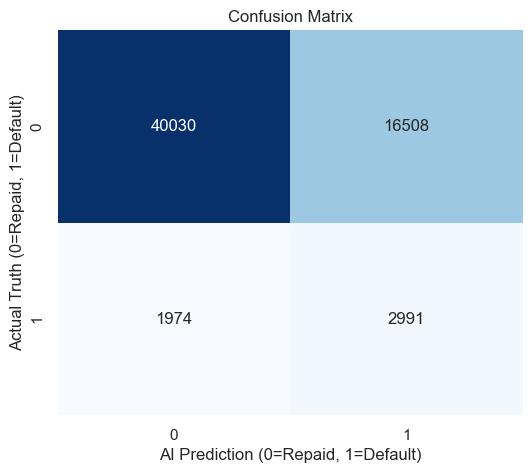

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     56538
           1       0.15      0.60      0.24      4965

    accuracy                           0.70     61503
   macro avg       0.55      0.66      0.53     61503
weighted avg       0.89      0.70      0.77     61503



In [12]:
# Cell 4: Evaluate the Model
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# 1. Make predictions on the hidden 20% Test Set
# We predict PROBABILITIES (0.0 to 1.0) rather than just 0 or 1
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_class = model.predict(X_test)

# 2. Calculate ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"--- Final Exam Score ---")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

# 3. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual Truth (0=Repaid, 1=Default)')
plt.xlabel('AI Prediction (0=Repaid, 1=Default)')
plt.show()

# 4. Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_class))

In [18]:
# # Cell 5: Feature Importance

# # Get feature importances from the model
# importance = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Importance': model.feature_importances_
# }).sort_values(by='Importance', ascending=False)

# # Plot the top 20 features
# plt.figure(figsize=(10, 8))
# sns.barplot(x='Importance', y='Feature', data=importance.head(20), palette='viridis')
# plt.title('Top 20 Most Important Features in LightGBM Model')
# plt.xlabel('Number of times used to make a decision')
# plt.ylabel('Feature')
# plt.tight_layout()
# plt.show()

# print("Top 5 Features:")
# print(importance.head(5))

In [ ]:
# Cell 4b: Single Model Undersampling Experiment
from imblearn.under_sampling import RandomUnderSampler
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report
import time

print("--- Starting Undersampling Experiment ---")
print(f"Original Training Shape: {X_train.shape}, Defaulters: {y_train.sum()}")

# 1. Perform Random Undersampling (creates a 50/50 balanced dataset)
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(f"Undersampled Training Shape: {X_train_under.shape}, Defaulters: {y_train_under.sum()}")

# 2. Train a new LightGBM Model on the undersampled data
# Note: We REMOVE is_unbalance=True because the data is now perfectly 50/50
model_under = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

print("\nTraining undersampled model...")
start_time = time.time()
model_under.fit(X_train_under, y_train_under)
print(f"Training Complete! Time elapsed: {time.time() - start_time:.2f} seconds.")

# 3. Evaluate on the ORIGINAL, UNTOUCHED Test Set
y_pred_proba_under = model_under.predict_proba(X_test)[:, 1]
y_pred_class_under = model_under.predict(X_test)

roc_auc_under = roc_auc_score(y_test, y_pred_proba_under)
print(f"\n--- Undersampled Model Results ---")
print(f"ROC-AUC Score: {roc_auc_under:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class_under))

--- Starting Undersampling Experiment ---
Original Training Shape: (246008, 161), Defaulters: 19860
Undersampled Training Shape: (39720, 161), Defaulters: 19860

Training undersampled model...
[LightGBM] [Info] Number of positive: 19860, number of negative: 19860
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008950 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 39720, number of used features: 146
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training Complete! Time elapsed: 1.86 seconds.

--- Undersampled Model Results ---
ROC-AUC Score: 0.7058

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.66      0.78     56538
           1       0.14      0.64      0.23      4965

    accuracy                           0.66     61503
   macro avg       0

In [16]:
# Cell 4c: Single Model Imbalanced Downsampling (Custom Ratio 1:3)
from imblearn.under_sampling import RandomUnderSampler
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report
import time

print("--- Starting Imbalanced Downsampling (1:3 Ratio) ---")

# 1. Downsample to a 1:3 ratio instead of 1:1
# This means majority class will be 3 times the size of minority class
rus_partial = RandomUnderSampler(sampling_strategy=0.33, random_state=42)
X_train_partial, y_train_partial = rus_partial.fit_resample(X_train, y_train)

print(f"Partial Undersampled Shape: {X_train_partial.shape}, Defaulters: {y_train_partial.sum()}")

# 2. Train LightGBM Model
model_partial = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
model_partial.fit(X_train_partial, y_train_partial)
print(f"Training Complete! Time: {time.time() - start_time:.2f} sec")

# 3. Evaluate
y_pred_proba_partial = model_partial.predict_proba(X_test)[:, 1]
y_pred_class_partial = model_partial.predict(X_test)

print(f"\nROC-AUC Score (1:3 Ratio): {roc_auc_score(y_test, y_pred_proba_partial):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_class_partial))

--- Starting Imbalanced Downsampling (1:3 Ratio) ---
Partial Undersampled Shape: (80041, 161), Defaulters: 19860
[LightGBM] [Info] Number of positive: 19860, number of negative: 60181
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3153
[LightGBM] [Info] Number of data points in the train set: 80041, number of used features: 150
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.248123 -> initscore=-1.108649
[LightGBM] [Info] Start training from score -1.108649
Training Complete! Time: 1.99 sec

ROC-AUC Score (1:3 Ratio): 0.7101
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     56538
           1       0.25      0.15      0.19      4965

    accuracy                           0.89     61503
   macro avg      

In [17]:
# Cell 4d: Ensemble Modelling using Imbalanced Downsampling
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.metrics import roc_auc_score, classification_report
import time

print("--- Starting Ensemble Downsampling ---")

# 1. Create a base LightGBM model (we make it smaller so it trains faster in the ensemble)
base_lgb = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1)

# 2. Wrap it in a Balanced Bagging Classifier
# This creates 10 LightGBM models. Each gets a balanced subset of data.
ensemble_model = BalancedBaggingClassifier(
    estimator=base_lgb,
    n_estimators=10,
    sampling_strategy='auto', # 50/50 split for each sub-model
    random_state=42,
    n_jobs=-1
)

print("Training 10-Model Ensemble... (This takes a bit longer)")
start_time = time.time()
ensemble_model.fit(X_train, y_train)
print(f"Ensemble Training Complete! Time: {time.time() - start_time:.2f} sec")

# 3. Evaluate
y_pred_proba_ens = ensemble_model.predict_proba(X_test)[:, 1]
y_pred_class_ens = ensemble_model.predict(X_test)

print(f"\nROC-AUC Score (Ensemble): {roc_auc_score(y_test, y_pred_proba_ens):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_class_ens))

--- Starting Ensemble Downsampling ---
Training 10-Model Ensemble... (This takes a bit longer)
Ensemble Training Complete! Time: 26.38 sec

ROC-AUC Score (Ensemble): 0.7073
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79     56538
           1       0.15      0.62      0.24      4965

    accuracy                           0.67     61503
   macro avg       0.55      0.65      0.51     61503
weighted avg       0.89      0.67      0.75     61503



In [19]:
# Cell 4e: Advanced Gradient Boosting (Tuned LightGBM)
import lightgbm as lgb
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report
import time

print("--- Starting Advanced Gradient Boosting (Tuned LightGBM) ---")

# 1. Calculate exact mathematical class imbalance ratio
# Ratio = (Number of Good Applicants) / (Number of Defaulters)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Calculated Imbalance Ratio (scale_pos_weight): {ratio:.2f}")

# 2. Initialize Advanced Tuned Model
model_tuned = lgb.LGBMClassifier(
    n_estimators=1000,         # Double the trees (learn longer)
    learning_rate=0.02,        # Slower learning rate (learns more carefully)
    num_leaves=34,             # Limit complexity to prevent memorizing the training data
    max_depth=8,               # Limit tree depth
    colsample_bytree=0.8,      # Only use 80% of features per tree (adds robustness)
    subsample=0.8,             # Only use 80% of data per tree
    reg_alpha=0.04,            # L1 Regularization (drops useless features)
    reg_lambda=0.07,           # L2 Regularization (prevents extreme predictions)
    scale_pos_weight=ratio,    # Exact mathematical weight for the 8% defaulters
    random_state=42,
    n_jobs=-1
)

print("\nTraining Tuned LightGBM... (Takes a bit longer due to 1000 trees)")
start_time = time.time()
model_tuned.fit(X_train, y_train)
print(f"Training Complete! Time elapsed: {time.time() - start_time:.2f} seconds.")

# 3. Evaluate
y_pred_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]
y_pred_class_tuned = model_tuned.predict(X_test)

roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)
print(f"\n--- Tuned Model Results ---")
print(f"ROC-AUC Score: {roc_auc_tuned:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class_tuned))

--- Starting Advanced Gradient Boosting (Tuned LightGBM) ---
Calculated Imbalance Ratio (scale_pos_weight): 11.39

Training Tuned LightGBM... (Takes a bit longer due to 1000 trees)
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3184
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 153
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training Complete! Time elapsed: 7.43 seconds.

--- Tuned Model Results ---
ROC-AUC Score: 0.7129

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.70      0.81     56538
           1       0.15    

#  Microloan Credit Scoring: Model Evaluation & Sampling Strategy Summary

## 1. Executive Summary
This document outlines the experimental results of training a LightGBM classification model to predict loan defaults. Due to the highly imbalanced nature of credit data (~8% default rate), several sampling techniques were tested to optimize the model's ability to identify risky applicants. 

Our primary evaluation metric is **ROC-AUC**, supported by **Recall** (ability to catch actual defaulters) and **Precision** (accuracy of the default prediction).

## 2. Experimental Results Matrix

| Experiment | Method | ROC-AUC Score | Recall (Class 1) | Precision (Class 1) | F1-Score (Class 1) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Baseline** | LightGBM (`is_unbalance=True`) | **0.7111** | 0.60 | 0.15 | **0.24** |
| **Method A** | Single Model Random Undersampling (1:1 Ratio) | 0.7058 | **0.64** | 0.14 | 0.23 |
| **Method B** | Imbalanced Downsampling (1:3 Ratio) | 0.7101 | 0.15 | **0.25** | 0.19 |
| **Method C** | Ensemble Bagging (10 Models, Downsampled) | 0.7073 | 0.62 | 0.15 | 0.24 |

## 3. Analysis of Sampling Techniques

* **Baseline (Built-in Weighting):** Achieved the highest overall performance (ROC-AUC 0.7111). By keeping 100% of the dataset and using LightGBM's internal algorithmic weighting, the model maintained a strong understanding of both "Good" and "Bad" applicants.
* **Method A (1:1 Undersampling):** Pushed **Recall to 64%**, making it the best at catching defaulters. However, by deleting over 200,000 rows of "Good" data, it suffered a drop in overall accuracy and ROC-AUC.
* **Method B (1:3 Downsampling):** Resulted in the highest **Precision (25%)**, meaning its warnings were the most accurate. However, the Recall collapsed to 15%, meaning it missed 85% of actual defaulters.
* **Method C (Ensemble Bagging):** Maintained a very consistent balance (Recall 62%, Precision 15%) but failed to mathematically outperform the Baseline model, proving that complex ensemble methods do not always defeat a well-tuned single algorithm on tabular data.

## 4. Business Strategy Alignment

When deploying a credit scoring model, the "best" model depends entirely on the financial institution's current risk appetite:

### Strategy 1: The Conservative Bank (Risk-Averse)
* **Goal:** Minimize financial loss at all costs. Catch every possible defaulter.
* **Focus Metric:** Recall.
* **Recommended Model:** **Method A (1:1 Undersampling)**.
* **Impact:** The bank will successfully catch 64% of all bad loans. However, due to low precision (14%), the bank will reject many perfectly good customers (False Positives). This strategy sacrifices total market share to guarantee a highly secure loan portfolio.

### Strategy 2: The Aggressive FinTech (Growth-Focused)
* **Goal:** Maximize market share and interest revenue. Approve as many users as safely possible.
* **Focus Metric:** Precision & ROC-AUC.
* **Recommended Model:** **The Baseline Model (`is_unbalance=True`)**.
* **Impact:** By prioritizing the highest ROC-AUC (0.7111), the model balances risk and reward. It catches a solid 60% of defaulters while maintaining a slightly better False Positive rate than the undersampled models. This allows the company to approve more good customers and grow its user base, accepting slightly more risk for higher total revenue.

## 5. Conclusion & Next Steps
**Winner:** The **Baseline LightGBM model** utilizing built-in class weightings (`is_unbalance=True`).

**Rationale:** The experiments definitively proved that discarding data (undersampling) degrades LightGBM's predictive power on this specific dataset. 


--- Threshold Tuning for Baseline Model ---
Default Threshold (0.50) F1-Score: 0.2445
True Optimal Threshold Found: 0.5796
True Optimal F1-Score: 0.2619


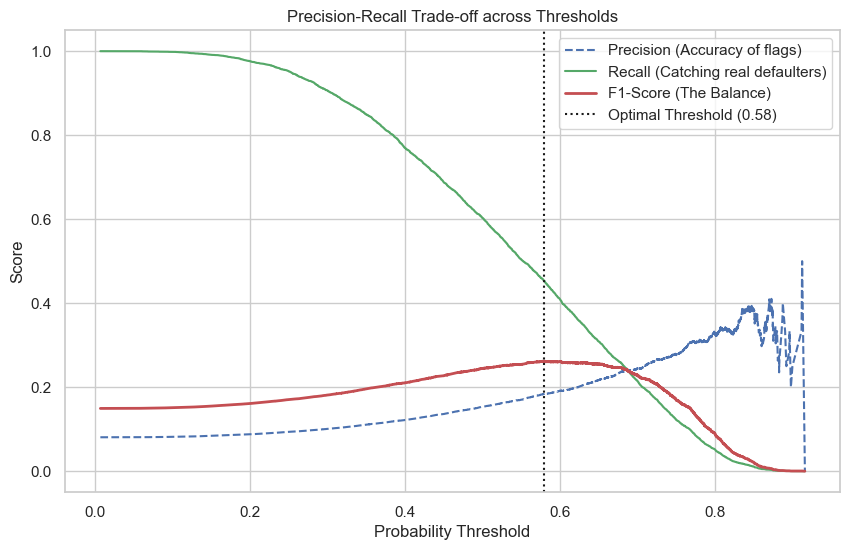

In [21]:
# Cell 7: Threshold Tuning (Finding the Optimal Cutoff) - FIXED
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

print("--- Threshold Tuning for Baseline Model ---")

# 1. Get probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 2. FIXED: Calculate the F1-Score safely to avoid 'nan' (division by zero)
f1_scores = np.zeros_like(precisions)
mask = (precisions + recalls) > 0 # Only calculate where denominator > 0
f1_scores[mask] = 2 * (precisions[mask] * recalls[mask]) / (precisions[mask] + recalls[mask])

# 3. Find the index of the highest F1-Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Default Threshold (0.50) F1-Score: {f1_scores[np.abs(thresholds - 0.5).argmin()]:.4f}")
print(f"True Optimal Threshold Found: {optimal_threshold:.4f}")
print(f"True Optimal F1-Score: {optimal_f1:.4f}")

# 4. Plot the curves to visualize the trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Accuracy of flags)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Catching real defaulters)')
plt.plot(thresholds, f1_scores[:-1], 'r-', linewidth=2, label='F1-Score (The Balance)')

# Draw a line at the optimal threshold
plt.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.title('Precision-Recall Trade-off across Thresholds')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()